<a href="https://colab.research.google.com/github/njokinjuguna/ml-learning-labs/blob/main/Transfer_learning_in_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# !pip install tensorflow_hub

In [ ]:
import numpy as np
import pandas as pd
import PIL.Image as Image

import tensorflow as tf
import tf_keras as keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
import tensorflow_hub as hub

from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import MobileNetV2

import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
import PIL
import cv2


import warnings
warnings.filterwarnings('ignore')


In [ ]:
IMAGE_SHAPE=(224,224)

classifier = hub.KerasLayer(
    "https://tfhub.dev/google/tf2-preview/mobilenet_v2/classification/4",input_shape=IMAGE_SHAPE+(3,)
)

In [ ]:
print(type(classifier))

<class 'tensorflow_hub.keras_layer.KerasLayer'>


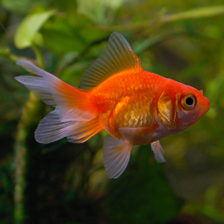

In [ ]:
gold_fish=Image.open("goldfish.jpg").resize(IMAGE_SHAPE)
gold_fish

In [ ]:
scaled_gold_fish=np.array(gold_fish)/255
scaled_gold_fish.shape

(224, 224, 3)

In [ ]:
predictions = classifier(
    tf.convert_to_tensor(
        np.expand_dims(scaled_gold_fish, axis=0),
        dtype=tf.float32
    )
)
print(predictions.shape)

(1, 1001)


In [ ]:
np.argmax(predictions)

np.int64(2)

In [ ]:
#lets confirm if our prediction is correct
with open("ImageNetLabels.txt", "r") as f:
  image_labels=f.read().splitlines()
image_labels[:10]

['background',
 'tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen']

In [ ]:
#at index 2 the label correct label is goldfish ,so our prediction is correct

### Load flowers dataset

In [ ]:
#load image dataset from google to our local folder called datasets

dataset_url="https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)
data_dir = Path(data_dir)



In [ ]:
print(type(data_dir))

<class 'pathlib.PosixPath'>


In [ ]:
if (data_dir / "flower_photos").exists():
    data_dir = data_dir / "flower_photos"

print("Dataset location:", data_dir)

image_count = len([
    f for f in data_dir.rglob("*")
    if f.suffix.lower() in [".jpg", ".jpeg"]
])

print(image_count)

Dataset location: /root/.keras/datasets/flower_photos/flower_photos
3670


In [ ]:
print(type(data_dir))

<class 'pathlib.PosixPath'>


In [ ]:
#lets now make a python dictonary for the flowers
flower_images_dict={
    'roses':list(data_dir.glob('roses/*')),
    'daisy':list(data_dir.glob('daisy/*')),
    'dandelion':list(data_dir.glob('dandelion/*')),
    'sunflowers':list(data_dir.glob('sunflowers/*')),
    'tulips':list(data_dir.glob('tulips/*')),

}

In [ ]:
flower_images_dict['roses']

[PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/2535466393_6556afeb2f_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/3407482427_49d5c75291_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/9369421752_db1ab2a6a4_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/3713368809_eba7fa2fbf_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/7525783408_0999483bf4_m.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/3179751458_9646d839f6_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/15094168139_8f636ffa1d_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/9609569441_eeb8566e94.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/8667746487_781af9e615_n.jpg'),
 PosixPath('/root/.keras/datasets/flower_photos/flower_photos/roses/15602874619_03fd934bed.jpg'),
 PosixPath('

In [ ]:
flowers_labels_dict={
    'roses':0,
    'daisy':1,
    'dandelion':2,
    'sunflowers':3,
    'tulips':4,
}

In [ ]:
img=cv2.imread(str(flower_images_dict['roses'][0]))
img.shape

(240, 191, 3)

In [ ]:
#scale the roses images
cv2.resize(img,IMAGE_SHAPE).shape

(224, 224, 3)

In [ ]:
#lets create the X and Y data split
X,y=[],[]
for flower_name,images in flower_images_dict.items():
  for image in images:
    img=cv2.imread(str(image))
    resized_img=cv2.resize(img,IMAGE_SHAPE)
    X.append(resized_img)
    y.append(flowers_labels_dict[flower_name])

array([[[239, 230, 227],
        [240, 231, 227],
        [240, 231, 227],
        ...,
        [232, 229, 221],
        [233, 230, 222],
        [233, 231, 221]],

       [[238, 229, 225],
        [239, 230, 226],
        [238, 229, 225],
        ...,
        [233, 230, 223],
        [232, 229, 221],
        [231, 229, 219]],

       [[237, 229, 224],
        [238, 229, 225],
        [238, 229, 225],
        ...,
        [233, 230, 222],
        [231, 228, 220],
        [229, 227, 217]],

       ...,

       [[225, 206, 191],
        [223, 204, 189],
        [222, 203, 187],
        ...,
        [149, 127,  92],
        [148, 126,  91],
        [148, 126,  91]],

       [[223, 206, 193],
        [222, 204, 189],
        [223, 203, 187],
        ...,
        [134, 111,  84],
        [133, 111,  83],
        [131, 110,  81]],

       [[223, 206, 193],
        [222, 204, 189],
        [222, 203, 187],
        ...,
        [ 92,  66,  58],
        [ 91,  65,  57],
        [ 90,  65,  55]]], dtype=uint8)
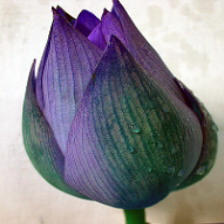

In [ ]:
X[0]


In [ ]:
# Lets PUT them in an array so we scale all the values for X and y after splitting
X=np.array(X)
y=np.array(y)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=0)

In [ ]:
X_train_scaled=X_train/255
X_test_scaled=X_test/255


In [ ]:
#Make prediction using pre-trained model on new flowers dataset
X[0].shape


(224, 224, 3)

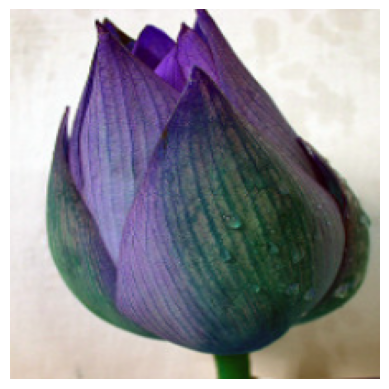

In [ ]:
plt.axis('off')
plt.imshow(X[0])

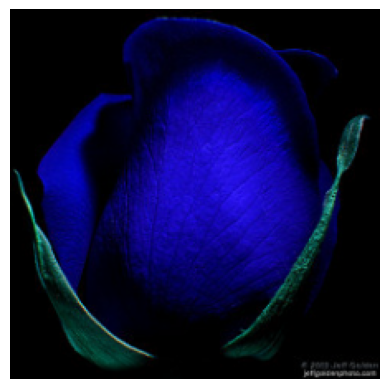

In [ ]:
plt.axis('off')
plt.imshow(X[1])

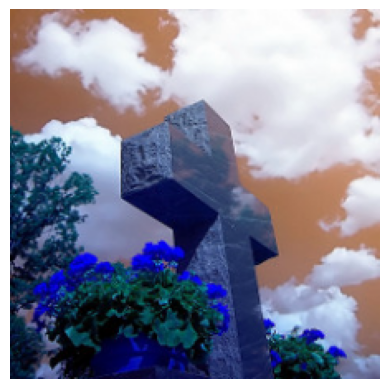

In [ ]:
plt.axis('off')
plt.imshow(X[2])

In [ ]:
batch=np.array([X[0],X[1],X[2]])


predictions = classifier(
    tf.convert_to_tensor(
        batch,
        dtype=tf.float32
    )
)
predictions

<tf.Tensor: shape=(3, 1001), dtype=float32, numpy=
array([[ 0.39314637,  0.8258095 ,  1.3083564 , ..., -1.9741489 ,
        -2.725585  ,  3.092734  ],
       [ 0.35810044, -1.0510147 ,  0.37348115, ..., -1.6322967 ,
        -0.91119826,  4.0337577 ],
       [ 0.15169439,  0.14604057,  2.421114  , ..., -1.0709822 ,
        -0.64770705,  3.5951016 ]], dtype=float32)>

In [ ]:
np.argmax(predictions,axis=1)

array([592, 571, 795])

In [ ]:
#lets confirm if our prediction is correct
with open("ImageNetLabels.txt", "r") as f:
  image_labels=f.read().splitlines()
image_labels[795]

'shower curtain'

In [ ]:
#as you can see above,we have used the pre trained model which we called classifier if you recall(check the first cells)..
#we have used it to predict our flower datset and clearly its predicting but with the wrong items because,
#our dataset labels are different from that of the classifier the imageNetLabel... yani the classifiers(y label are different;)
#therefore we need to retrain the model and freeze some layers
#meaning we need to just train the last layer which does the classification and freeze the hidden layers(as we are not changing/training them) as shown in the image below

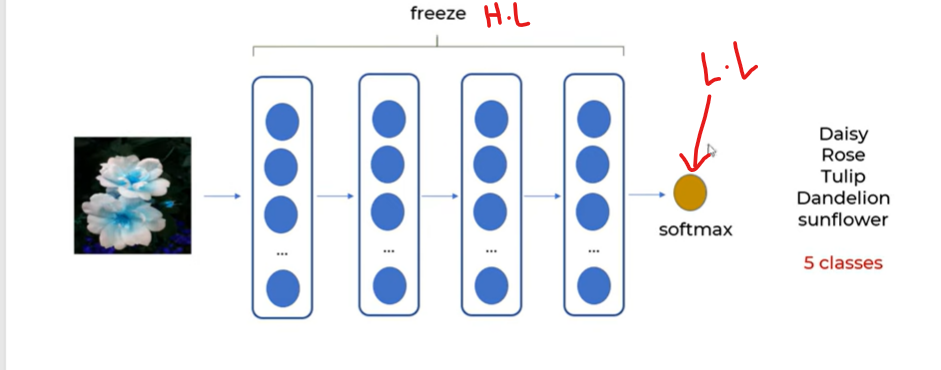

In [ ]:
#therefore we will call the same pre trained model but with the hidden layers froozen so that we can simply train the last layer
# this parameter trainable = False means freeze the layers in the above pre trained model..meaning thier weights will not be updated(no backpropagation)

pre_trained_model_without_top_layer = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

pre_trained_model_without_top_layer.trainable = False


In [ ]:
#now after setting up our pretained model having froozen the hidden layers lets now use the model to tarin the last layer/classification layer so that our flower dataset is correctly classsified
num_of_flowers=5 #output

pre_trained_flower_model = tf.keras.Sequential([
    pre_trained_model_without_top_layer,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(num_of_flowers, activation='softmax')
])

pre_trained_flower_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
pre_trained_flower_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

pre_trained_flower_model.fit(X_train_scaled,y_train,epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.6668 - loss: 0.8953
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.8412 - loss: 0.4668
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.8805 - loss: 0.3701
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.9008 - loss: 0.3149
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9179 - loss: 0.2746


In [ ]:
pre_trained_flower_model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 18s 436ms/step - accuracy: 0.8486 - loss: 0.4020


[0.40202048420906067, 0.8485838770866394]